Generate examples for Image datasets using GANs.

Operations to be performed:
1) Import the required Python libraries
2) Design Generator, Discriminator
3) Train the learning model
4) Plot Loss value vs Epoch
5) Test the model performance

## Step 1: Import Required Libraries and Prepare Dataset
We use the MNIST image dataset (28x28 grayscale digits) and normalize pixel values to the range [-1, 1] for stable GAN training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load image dataset (MNIST)
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1] and add channel dimension
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

# Use a subset for faster GAN training
x_train = x_train[:20000]

batch_size = 128
buffer_size = x_train.shape[0]
latent_dim = 64
epochs = 15

train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(buffer_size).batch(batch_size, drop_remainder=True)

print("Dataset shape:", x_train.shape)
print("Batch size:", batch_size)
print("Latent dimension:", latent_dim)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Dataset shape: (20000, 28, 28, 1)
Batch size: 128
Latent dimension: 64


## Step 2: Design Generator and Discriminator
Generator maps noise vectors to synthetic images. Discriminator classifies images as real (1) or fake (0).

In [2]:
def build_generator(latent_dim=64):
    model = models.Sequential(name="Generator")
    model.add(layers.Input(shape=(latent_dim,)))
    model.add(layers.Dense(7 * 7 * 128, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Reshape((7, 7, 128)))

    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=1, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=0.2))

    model.add(layers.Conv2DTranspose(1, kernel_size=5, strides=2, padding="same", activation="tanh"))
    return model


def build_discriminator():
    model = models.Sequential(name="Discriminator")
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(32, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(64, kernel_size=5, strides=2, padding="same"))
    model.add(layers.LeakyReLU(negative_slope=0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))
    return model


generator = build_generator(latent_dim)
discriminator = build_discriminator()

generator.summary()
discriminator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6272)           │       401,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6272)           │        25,088 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 64)       │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 32)     │        51,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           801 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,681 (2.61 MB)

 Trainable params: 670,945 (2.56 MB)

 Non-trainable params: 12,736 (49.75 KB)

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,233 (215.75 KB)

 Trainable params: 55,233 (215.75 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Loss and optimizers
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)
g_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
d_optimizer = optimizers.Adam(learning_rate=2e-4, beta_1=0.5)


def discriminator_loss(real_output, fake_output):
    real_labels = tf.ones_like(real_output)
    fake_labels = tf.zeros_like(fake_output)
    real_loss = bce(real_labels, real_output)
    fake_loss = bce(fake_labels, fake_output)
    return real_loss + fake_loss


def generator_loss(fake_output):
    fool_labels = tf.ones_like(fake_output)
    return bce(fool_labels, fake_output)


@tf.function
def train_step(real_images):
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(g_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return g_loss, d_loss

## Step 3: Train the GAN Model
This loop trains both networks and stores generator/discriminator loss per epoch.

In [4]:
g_losses = []
d_losses = []

for epoch in range(1, epochs + 1):
    epoch_g = []
    epoch_d = []

    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)
        epoch_g.append(float(g_loss.numpy()))
        epoch_d.append(float(d_loss.numpy()))

    g_mean = float(np.mean(epoch_g))
    d_mean = float(np.mean(epoch_d))

    g_losses.append(g_mean)
    d_losses.append(d_mean)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | G Loss: {g_mean:.4f} | D Loss: {d_mean:.4f}")

print("Training complete.")

Epoch 01/15 | G Loss: 0.6976 | D Loss: 1.0979
Epoch 05/15 | G Loss: 0.7543 | D Loss: 1.3304
Epoch 10/15 | G Loss: 0.7666 | D Loss: 1.3234
Epoch 15/15 | G Loss: 0.7374 | D Loss: 1.3523
Training complete.


## Step 4: Plot Loss Value vs Epoch

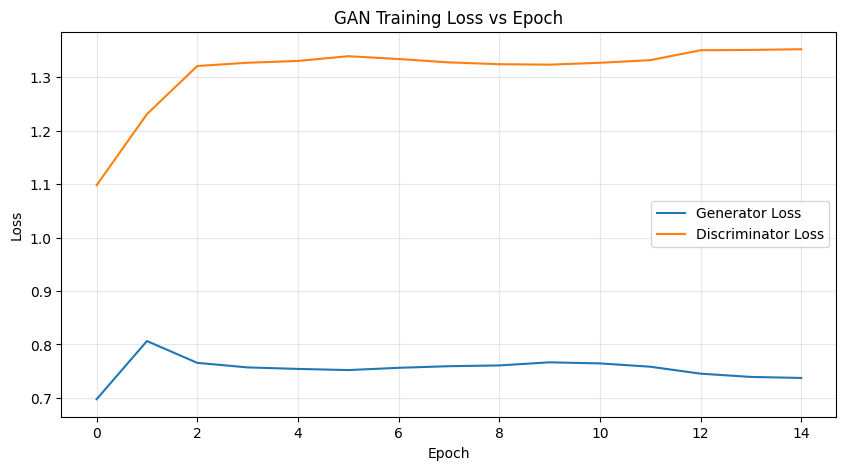

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 5: Test Model Performance
Generate sample images and compute discriminator confidence on real vs generated samples.

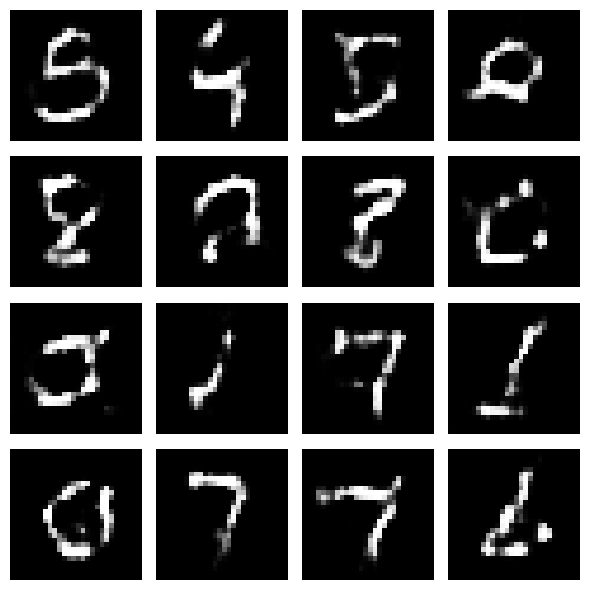

Discriminator Real Accuracy: 27.00%
Discriminator Fake Accuracy: 96.30%
Discriminator Overall Accuracy: 61.65%


In [6]:
def generate_and_plot_samples(generator_model, latent_dim=64, num_images=16):
    noise = tf.random.normal([num_images, latent_dim])
    generated = generator_model(noise, training=False)

    # Convert back from [-1, 1] to [0, 1] for display
    generated = (generated + 1.0) / 2.0

    plt.figure(figsize=(6, 6))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(generated[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def discriminator_performance(discriminator_model, real_images, generator_model, latent_dim=64, sample_size=1000):
    sample_size = min(sample_size, real_images.shape[0])

    idx = np.random.choice(real_images.shape[0], sample_size, replace=False)
    real_sample = real_images[idx]

    noise = tf.random.normal([sample_size, latent_dim])
    fake_sample = generator_model(noise, training=False)

    real_pred = discriminator_model(real_sample, training=False).numpy().flatten()
    fake_pred = discriminator_model(fake_sample, training=False).numpy().flatten()

    real_acc = np.mean(real_pred > 0.5)
    fake_acc = np.mean(fake_pred < 0.5)
    overall_acc = (real_acc + fake_acc) / 2.0

    print(f"Discriminator Real Accuracy: {real_acc * 100:.2f}%")
    print(f"Discriminator Fake Accuracy: {fake_acc * 100:.2f}%")
    print(f"Discriminator Overall Accuracy: {overall_acc * 100:.2f}%")


# Visual test of generator output
generate_and_plot_samples(generator, latent_dim=latent_dim, num_images=16)

# Quantitative discriminator test
discriminator_performance(discriminator, x_train, generator, latent_dim=latent_dim, sample_size=1000)